# 2.1 Optimizing Lennard-Jones Clusters

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume II — Energy Landscapes & Optimization",
    number="2.1",
    title="Optimizing Lennard-Jones Clusters",
    blurb="The pair potential of a noble-gas solid, the rugged energy landscape "
    "it builds, and the geometry optimization at the heart of the original CP2K "
    "exercise: relaxing two 38-atom seeds, tracking energy, asphericity, and "
    "order parameters down to the global minimum, and telling a crystal from an "
    "icosahedron.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 3 (Lennard-Jones clusters)",
)

<ECP header: 2903 chars of HTML>

## Notebook overview

A handful of argon atoms, left to themselves, will settle into a compact little
ball. *Which* ball is a surprisingly deep question. The atoms interact through
the simplest realistic pair potential there is, yet the energy of an $N$-atom
cluster, as a function of all $3N$ coordinates, is a landscape of staggering
complexity, with a number of local minima that grows roughly exponentially with
$N$. The 38-atom cluster is the textbook example: two competing **funnels** lead
to two very different deep structures, and which one a geometry optimization
finds depends entirely on where it starts.

This is the exercise from Lecture 3, and we follow it closely. The course ran the
optimizations in **CP2K** on the Euler cluster; we show that very input deck and
then reproduce it in Python, because CP2K's classical engine here *is* the
Lennard-Jones potential and nothing more. We relax the two 38-atom seeds the
course used, a truncated octahedron and an icosahedron, and analyse each
optimization the way the original did: energy, **asphericity**, and the
**Steinhardt order parameter** $Q_6$ as functions of optimization step. The
payoff is the same one the course was built around. The truncated octahedron is
the global minimum, a face-centred-cubic crystal fragment, and $Q_6$ tells it
apart from the icosahedron at a glance.

> **Provenance.** This notebook develops **Lecture 3** of the course (Lennard-Jones
> clusters, energy landscapes, geometry optimization, and order parameters), an
> exercise **designed by the author (Raymond Amador)**. The original exercise drove
> CP2K's classical force field (the `geo-opt.inp` deck
> shown in Exercise 2) on the Euler cluster; since that force field is exactly the
> Lennard-Jones potential, the optimization is reproduced here in Python so it is
> self-contained and checkable, while the analysis (asphericity and $Q_6$ along
> the trajectory) mirrors the original. The full course credit is in the footer.

> **Reading a validation.** Each exercise closes with a check against something
> independent: an analytic minimum, a tabulated global-minimum energy, a known
> order-parameter value. A ✗ flags a mismatch to track down, not a verdict; a ✓ is
> strong evidence, not proof.

> **Units and scope.** We use reduced Lennard-Jones units, energies in
> $\varepsilon$ and lengths in $\sigma$, so $\varepsilon=\sigma=1$. The original
> deck uses argon's real values $\varepsilon=119.8\,k_B\,$K and $\sigma=3.405\,$Å,
> which is how the 38-atom coordinates (in Ångström) convert to reduced units
> below. For the landscapes picture see Wales, *Energy Landscapes*
> {cite}`wales-landscapes`; for tabulated global minima, the Cambridge Cluster
> Database {cite}`ccd`.

## Theory in brief

### The Lennard-Jones potential

Two noble-gas atoms a distance $r$ apart interact through the **Lennard-Jones**
pair potential

```{math}
:label: eq-lj
V(r) = 4\varepsilon\!\left[\left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^{6}\right].
```

The attractive $-(\sigma/r)^6$ is the dispersion (induced-dipole) interaction
that draws neutral atoms together; the repulsive $+(\sigma/r)^{12}$ models the
steep cost of overlapping closed electron shells, its exponent chosen as twice
the attractive one for convenience. The well has depth $\varepsilon$ at
$r_{\min}=2^{1/6}\sigma$, and $\sigma$ is where $V$ crosses zero. In reduced units
the minimum sits at $r_{\min}=2^{1/6}\approx1.122$ with $V(r_{\min})=-1$.

### Clusters and their energy landscape

The energy of a cluster of $N$ atoms is the sum over all pairs,

```{math}
:label: eq-lj-cluster
E(\mathbf r_1,\dots,\mathbf r_N) = \sum_{i<j} V(r_{ij}), \qquad r_{ij}=|\mathbf r_i-\mathbf r_j|.
```

As a function of the $3N$ coordinates this is a rugged surface with a vast number
of **local minima**, each a mechanically stable shape, separated by barriers.
Exactly one is the **global minimum**. A **geometry optimization** slides downhill
from a starting structure to the nearest local minimum, here with the quasi-Newton
L-BFGS method using the analytic forces $-\nabla E$. For $N=38$ the landscape has
two deep funnels: a wide one ending at an incomplete **Mackay icosahedron**, and a
narrow one holding the global minimum, a face-centred-cubic **truncated
octahedron** just $0.68\,\varepsilon$ lower. A downhill relaxation lands in
whichever funnel its starting structure belongs to (Exercise 4's disconnectivity
graph makes the picture concrete).

### Fingerprinting structure: asphericity and $Q_6$

To recognise *what* structure an optimization found, two rotation-invariant
numbers help. The **asphericity**, built from the principal moments of inertia
$I_1,I_2,I_3$,

```{math}
:label: eq-asphericity
A = \frac{(I_1-I_2)^2+(I_1-I_3)^2+(I_2-I_3)^2}{I_1^2+I_2^2+I_3^2},
```

is zero for a perfect sphere and grows as a cluster elongates. The **Steinhardt
order parameter** {cite}`steinhardt-1983` averages spherical harmonics over the
bonds and contracts over $m$,

```{math}
:label: eq-steinhardt
Q_l = \sqrt{\frac{4\pi}{2l+1}\sum_{m=-l}^{l}\Big|\tfrac{1}{N_b}\textstyle\sum_{\rm bonds} Y_{lm}(\hat{\mathbf r}_{ij})\Big|^2}.
```

The $l=6$ value cleanly separates structural families: a truncated-octahedron
(fcc) cluster gives $Q_6\approx0.57$, while the five-fold symmetry of an
icosahedron makes its bond contributions largely cancel, leaving $Q_6\approx0.13$.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, basinhopping
from scipy.spatial.distance import pdist, squareform

from ecp import validate

rng = np.random.default_rng(0)
RMIN = 2.0 ** (1.0 / 6.0)            # Lennard-Jones minimum separation (reduced units)
SIGMA_AR = 3.405                     # argon sigma [Å], from the CP2K deck (Exercise 2)
INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "02-energy-landscapes", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz_traj(name):
    """Read a multi-frame .xyz trajectory and convert to reduced units.

    Parameters
    ----------
    name : str
        Trajectory file name (coordinates in Å).

    Returns
    -------
    list of numpy.ndarray
        One (N, 3) array per frame, each centred and divided by σ.
    """
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    frames = []
    for s in range(0, len(lines), n + 2):
        block = lines[s + 2:s + 2 + n]
        if len(block) < n:
            break
        P = np.array([[float(v) for v in ln.split()[1:4]] for ln in block])
        frames.append((P - P.mean(0)) / SIGMA_AR)
    return frames

# Spherical harmonics: SciPy renamed sph_harm -> sph_harm_y (n, m, theta, phi).
# Support both so the notebook runs on older SciPy (Colab/Binder) too.
try:
    from scipy.special import sph_harm_y
    def _Ylm(l, m, theta, phi):
        return sph_harm_y(l, m, theta, phi)
except ImportError:                                       # pragma: no cover
    from scipy.special import sph_harm
    def _Ylm(l, m, theta, phi):
        return sph_harm(m, l, phi, theta)


def lj_energy_grad(x):
    """Lennard-Jones cluster energy and its gradient (Eq. eq-lj-cluster).

    Parameters
    ----------
    x : numpy.ndarray
        Atomic coordinates, shape (N, 3) or flat (3N,), in reduced units.

    Returns
    -------
    tuple
        ``(energy, grad)``: the total energy (float) and the flat gradient
        (shape (3N,)), for direct use as an optimizer's ``jac``.
    """
    x = np.asarray(x).reshape(-1, 3)
    d = x[:, None, :] - x[None, :, :]
    r2 = np.sum(d * d, axis=2)
    np.fill_diagonal(r2, np.inf)
    inv6 = r2 ** -3
    inv12 = inv6 * inv6
    energy = np.sum(4.0 * (inv12 - inv6)) / 2.0
    coeff = 4.0 * (-12.0 * inv12 + 6.0 * inv6) / r2
    grad = np.sum(coeff[:, :, None] * d, axis=1)
    return energy, grad.ravel()


def lj_energy(x):
    """Lennard-Jones cluster energy only (first return of ``lj_energy_grad``).

    Parameters
    ----------
    x : numpy.ndarray
        Atomic coordinates, shape (N, 3) or flat.

    Returns
    -------
    float
        Total Lennard-Jones energy in units of ε.
    """
    return lj_energy_grad(x)[0]

## Exercise 1 — The potential, the cluster energy, and the forces

Everything rests on the energy {eq}`eq-lj-cluster` and its gradient; an optimizer
converges far faster with exact forces than with finite differences.
Differentiating, the force on atom $i$ is
$-\nabla_i E=\sum_{j\neq i} 4\big(12\,r_{ij}^{-14}-6\,r_{ij}^{-8}\big)(\mathbf r_i-\mathbf r_j)$.
The smallest clusters give a quick correctness check: three atoms relax to an
equilateral triangle at $E=-3$, four to a regular tetrahedron at $E=-6$, every
bond sitting at the well bottom.

**Part a)** Plot $V(r)$, marking the minimum at $r_{\min}=2^{1/6}$, $V=-1$.
**Part b)** Confirm the dimer energy and the analytic forces (against finite
differences), and that L-BFGS recovers the exact 3- and 4-atom minima.

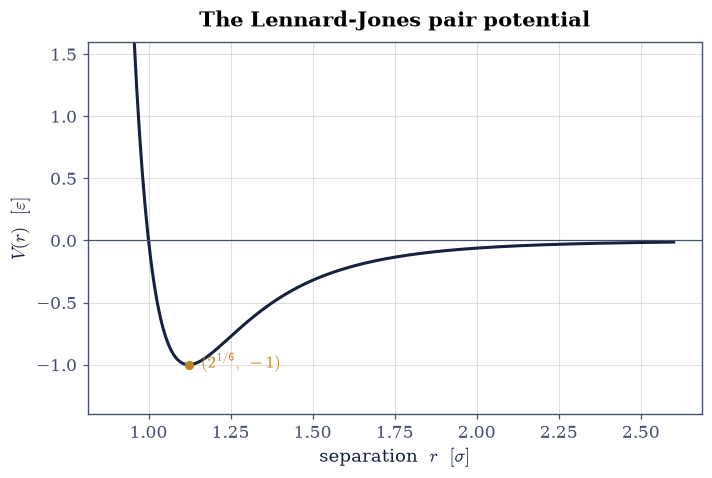

In [3]:
# (solution hidden on the public site)


In [4]:
# (solution hidden on the public site)


### Validation 1 — analytic forces and exact small-cluster minima

The dimer at $r_{\min}$ has energy $-1$; the analytic gradient matches a central
finite difference; and L-BFGS relaxes the 3- and 4-atom clusters to their exact
global minima $-3$ and $-6$.

In [5]:
validate.close(lj_energy([[0, 0, 0], [RMIN, 0, 0]]), -1.0, "LJ dimer minimum equals -1", rtol=1e-9)

x_test = RMIN * np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0], [0, 0, 1],
                          [1, 1, 0], [1, 0, 1.0]]) + 0.05 * rng.normal(size=(6, 3))
_, g = lj_energy_grad(x_test)
g_fd = np.zeros(x_test.size)
xf = x_test.ravel()
h = 1e-6
for k in range(x_test.size):
    xp, xm = xf.copy(), xf.copy()
    xp[k] += h
    xm[k] -= h
    g_fd[k] = (lj_energy(xp) - lj_energy(xm)) / (2 * h)
validate.close(g, g_fd, "analytic LJ forces match finite difference", rtol=1e-4, atol=1e-5)

e3, _ = local_minimize(RMIN * np.array([[0, 0, 0], [1, 0, 0], [0.5, 0.87, 0]]) + 0.1 * rng.normal(size=(3, 3)))
e4, _ = local_minimize(RMIN * np.array([[0, 0, 0], [1, 0, 0], [0.5, 0.87, 0], [0.5, 0.29, 0.82]]) + 0.1 * rng.normal(size=(4, 3)))
validate.close([e3, e4], [-3.0, -6.0], "L-BFGS recovers the exact LJ3 and LJ4 minima", rtol=1e-5)

✓  LJ dimer minimum equals -1   [got -1 vs expected -1 (rtol=1e-09, atol=1e-09)]
✓  analytic LJ forces match finite difference   [max|Δ| = 3.0246e-09 (rtol=0.0001, atol=1e-05)]
✓  L-BFGS recovers the exact LJ3 and LJ4 minima   [max|Δ| = 1.95399e-14 (rtol=1e-05, atol=1e-09)]


True

## Exercise 2 — The geometry optimization, as the course ran it

This exercise is the heart of the original. The course optimized a 38-atom argon
cluster with **CP2K**, whose `geo-opt.inp` deck sets `RUN_TYPE GEO_OPT` with a
`BFGS` optimizer and, crucially, a `METHOD Fist` (classical) force field that is a
single Lennard-Jones term for argon:

```text
&GEO_OPT
  OPTIMIZER BFGS
  MAX_ITER  500
&END GEO_OPT
...
&LENNARD-JONES
  atoms Ar Ar
  EPSILON 119.8        ! kelvin
  SIGMA   3.405        ! angstrom
  RCUT    8.4
&END LENNARD-JONES
```

The full deck ships with this notebook: {download}`geo-opt.inp <data/geo-opt.inp>`.
So CP2K here computes exactly {eq}`eq-lj-cluster`, and a faithful reproduction is
an L-BFGS relaxation of the same potential. We take the course's
truncated-**octahedron** seed (38 argon atoms, in Ångström), convert it to reduced
units by dividing by $\sigma=3.405\,$Å, and relax it. It descends into the **fcc**
funnel and reaches the global minimum.

**Part a)** Relax the octahedral seed. **Part b)** Show the initial and final
structures, and confirm the energy is the global minimum $-173.928\,\varepsilon$.

In [6]:
# (solution hidden on the public site)


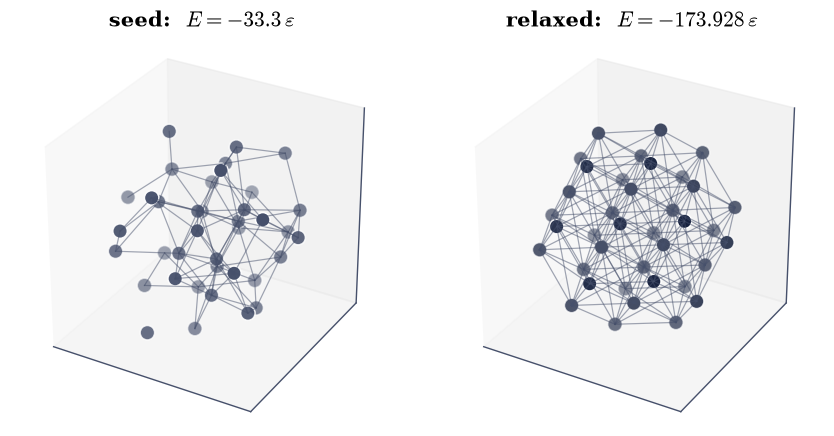

In [7]:
# (solution hidden on the public site)


### Validation 2 — the global minimum

The octahedral seed must relax to the global minimum of the 38-atom cluster, the
fcc truncated octahedron at $E=-173.928\,\varepsilon$ (Cambridge Cluster Database).

In [8]:
E_GLOBAL_38 = -173.928427
validate.close(e_octa, E_GLOBAL_38, "octahedral seed relaxes to the LJ38 global minimum", rtol=1e-3)

✓  octahedral seed relaxes to the LJ38 global minimum   [got -173.928 vs expected -173.928 (rtol=0.001, atol=1e-09)]


True

## Exercise 3 — Tracking the optimization: energy, asphericity, $Q_6$

The original exercise did not stop at the final energy; it watched the cluster
*order* as it relaxed, by computing observables along the optimization
trajectory. We do the same, on the course's **own committed optimization
trajectory** (`optimization-pos-1.xyz`, 186 frames from a disordered seed to the
global minimum), shipped here downsampled as
{download}`lj38-optimization.xyz <data/lj38-optimization.xyz>`. The
**asphericity** {eq}`eq-asphericity` measures how
far from spherical the cluster is, and the **Steinhardt** $Q_6$ {eq}`eq-steinhardt`
fingerprints the bond-orientational order. Plotted against optimization step, the
energy plunges, the asphericity stays small throughout (the cluster is compact from
the outset), and $Q_6$ climbs to the fcc value $\approx0.57$ as crystalline order
sets in.

**Part a)** Implement `asphericity(x)` and a global `steinhardt_q6(x)`.
**Part b)** Plot energy, asphericity, and $Q_6$ along the real CP2K trajectory.

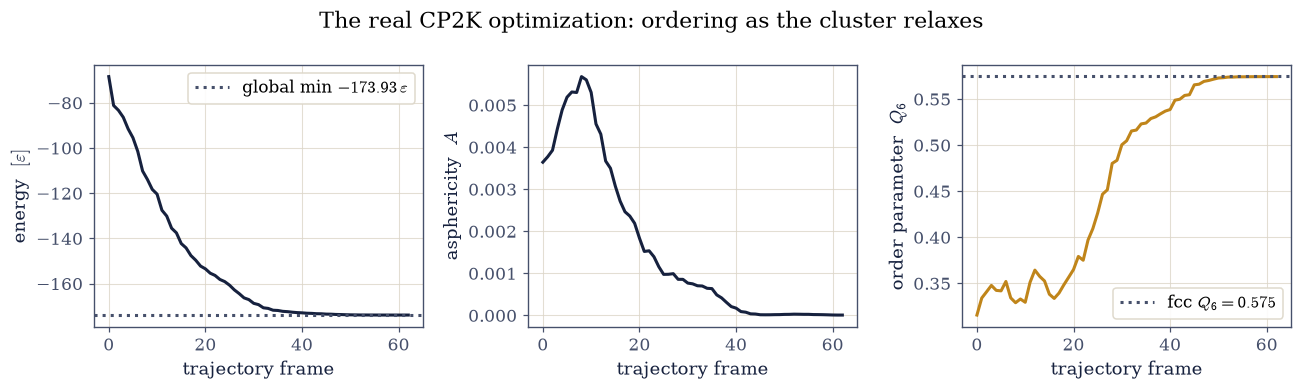

In [9]:
# (solution hidden on the public site)


### Validation 3 — the cluster orders into an fcc crystal

Along the trajectory the energy must decrease, and the final structure must be
nearly spherical ($A\to0$) with the fcc $Q_6\approx0.575$, the quantitative
signature of crystalline ordering.

In [10]:
validate.check(
    traj_E[-1] < traj_E[0] and traj_A[-1] < 0.02,
    "the real trajectory relaxes and rounds into a near-spherical crystal",
    f"E {traj_E[0]:.1f} → {traj_E[-1]:.1f}, asphericity {traj_A[0]:.3f} → {traj_A[-1]:.3f}",
)
validate.close(traj_Q6[-1], 0.5745, "final Q6 equals the fcc value 0.575", rtol=5e-2)

✓  the real trajectory relaxes and rounds into a near-spherical crystal   [E -68.4 → -173.9, asphericity 0.004 → 0.000]
✓  final Q6 equals the fcc value 0.575   [got 0.574371 vs expected 0.5745 (rtol=0.05, atol=1e-09)]


True

## Exercise 4 — The other funnel: the icosahedron

Now start from the course's **icosahedral** seed. It relaxes into the *other*
funnel, an incomplete Mackay icosahedron at $E=-173.252\,\varepsilon$, just
$0.68\,\varepsilon$ above the global minimum yet structurally unrelated. Its
five-fold symmetry is forbidden in any crystal, and the bond contributions to
$Q_6$ largely cancel, leaving $Q_6\approx0.13$, far below the fcc value. So the two
deepest structures of the 38-atom cluster sit in two separate funnels, and a
downhill optimization is trapped in whichever it starts in. The disconnectivity
graph, sketched below, is the standard picture of this {cite}`wales-landscapes`.

**Part a)** Relax the icosahedral seed and compare its energy, asphericity, and
$Q_6$ to the octahedron. **Part b)** Sketch the two-funnel disconnectivity graph.

In [11]:
# (solution hidden on the public site)


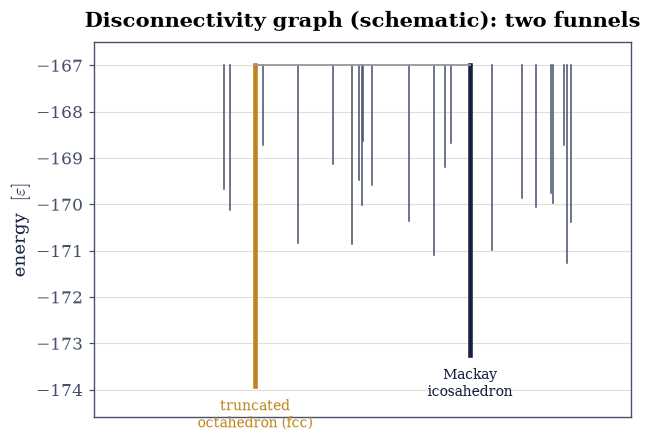

In [12]:
# (solution hidden on the public site)


### Validation 4 — two funnels, two fingerprints

The icosahedral seed must relax to its funnel minimum $-173.252\,\varepsilon$,
which lies *above* the truncated-octahedron global minimum. And the order
parameters must separate the two: the fcc truncated octahedron has the high
$Q_6\approx0.57$, the icosahedron the low $Q_6\approx0.13$.

In [13]:
validate.close(e_ico, E_ICOS_38, "icosahedral seed relaxes to its funnel minimum -173.252", rtol=1e-3)
validate.check(
    e_octa < e_ico and traj_Q6[-1] > 0.45 and q6_ico < 0.25,
    "the fcc truncated octahedron is the global minimum, and Q6 tells the two apart",
    f"E: octa {e_octa:.2f} < icos {e_ico:.2f};  Q6: octa {traj_Q6[-1]:.2f} vs icos {q6_ico:.2f}",
)

✓  icosahedral seed relaxes to its funnel minimum -173.252   [got -173.252 vs expected -173.252 (rtol=0.001, atol=1e-09)]
✓  the fcc truncated octahedron is the global minimum, and Q6 tells the two apart   [E: octa -173.93 < icos -173.25;  Q6: octa 0.57 vs icos 0.13]


True

## Exercise 5 — When there is no good seed: global optimization

The two seeds above were educated guesses, each already close to a funnel bottom.
Without such a guess, finding the global minimum means *searching* the landscape,
and the standard tool is **basin-hopping** {cite}`wales-doye-1997`: perturb the
current minimum, re-minimize, and accept the new minimum with a Metropolis
criterion, walking the staircase of basins. We demonstrate it on the 13-atom
cluster, small enough that basin-hopping reliably reaches its global minimum, a
perfect **icosahedron** at $E=-44.327\,\varepsilon$, from a random start. The
38-atom global minimum is far harder to reach this way, which is exactly what
motivates the replica-exchange sampling of Lecture 12.

**Part a)** Run basin-hopping on a random 13-atom cluster. **Part b)** Animate the
icosahedral global minimum and confirm its energy.

In [14]:
# (solution hidden on the public site)


In [15]:
# (solution hidden on the public site)


### Validation 5 — basin-hopping finds the LJ13 global minimum

From a random start, basin-hopping must reach the tabulated 13-atom global
minimum, $E=-44.327\,\varepsilon$.

In [16]:
validate.close(e13, -44.326801, "basin-hopping reaches the LJ13 icosahedral global minimum", rtol=1e-3)

✓  basin-hopping reaches the LJ13 icosahedral global minimum   [got -44.3268 vs expected -44.3268 (rtol=0.001, atol=1e-09)]


True

## Notebook summary

We built the Lennard-Jones cluster energy from its pair potential and analytic
forces, checked the forces against finite differences and small-cluster minima, and
relaxed the course's 38-atom seeds. The real CP2K optimisation trajectory carried
the cluster from a disordered seed down to the global minimum at $-173.93\,
\varepsilon$, with the asphericity staying small throughout and the Steinhardt $Q_6$
climbing to the fcc value $0.575$. The icosahedral funnel landed at a distinct, higher minimum
with $Q_6\approx0.13$, and basin-hopping found the LJ13 global minimum unaided.
These are three faces of one rugged landscape: local relaxation, structural
fingerprinting, and global search.

## Outlook

- **Reaching the LJ38 global without a seed.** Replica-exchange (parallel
  tempering) sampling, the subject of Lecture 12, crosses between funnels far more
  readily than basin-hopping and recovers the truncated octahedron from scratch.
- **Magic numbers.** The Mackay icosahedra continue at $N=55$ and $147$; track
  $Q_6$ and the asphericity as the structural families compete with growing $N$.
- **The full disconnectivity graph.** Enumerate minima and the transition states
  joining them to build the real graph rather than the schematic here; the 38-atom
  graph's two branches are a landmark in the energy-landscapes literature
  {cite}`wales-landscapes`.
- **Real units.** Argon's $\varepsilon=119.8\,k_B\,$K and $\sigma=3.405\,$Å from
  the deck turn these reduced energies into physical binding energies and the
  structures into real noble-gas nanoclusters.

### References

```{bibliography}
:filter: docname in docnames
```

In [17]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>